In [11]:
%reload_ext autoreload
%autoreload 2

import sys
import pickle
from tqdm import tqdm

import numpy as np
import healpy as hp

sys.path.append("..")
from utils.validation import roc_finite_sample_band

import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc_file("../../nptf-test/production/matplotlibrc")

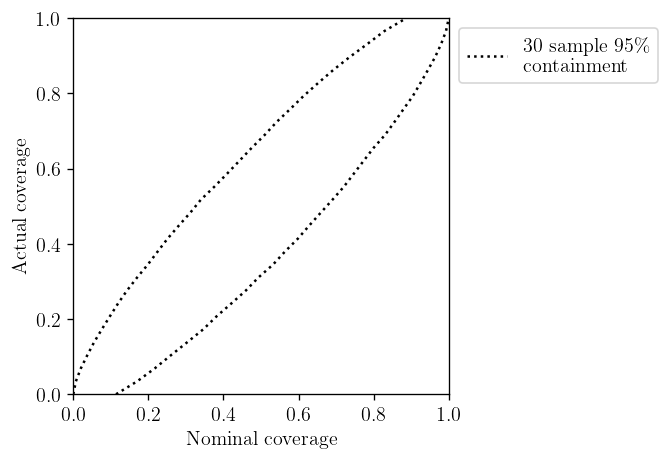

In [6]:
fig, ax = plt.subplots(1, 1)
n_run = 30
invcdf_lower, invcdf_upper = roc_finite_sample_band(n_run)
ax.plot(invcdf_upper, np.linspace(0, 1, n_run), 'k:', label=f'{n_run} sample 95\% \ncontainment')
ax.plot(invcdf_lower, np.linspace(0, 1, n_run), 'k:')
ax.set(aspect=1, xlim=(0, 1), ylim=(0, 1))
ax.set(xlabel='Nominal coverage', ylabel='Actual coverage')

fig.legend(bbox_to_anchor=(1, 1), loc='upper left', bbox_transform=ax.transAxes)
fig.tight_layout()

In [7]:
run_name = 'hmc_Dbase23fix_deltapsf_2_Mbase23fix_1exp_deltapsf'
z = pickle.load(open(f'../outputs/fit/{run_name}/p_nominal_actual_dict.p', 'rb'))
print(z.keys())

dict_keys(['S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'n1_dsk', 'n2_dsk', 'n3_dsk', 'sb1_dsk', 'lambdas_dsk', 'Sps_gce', 'n1_gce', 'n2_gce', 'n3_gce', 'sb1_gce', 'lambdas_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'C', 'zs'])


In [8]:
k = 'Sps_gce'

samples = []
for i in range(n_run):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{i}_n10000_ns0.p', 'rb'))
    samples.append(s[k])

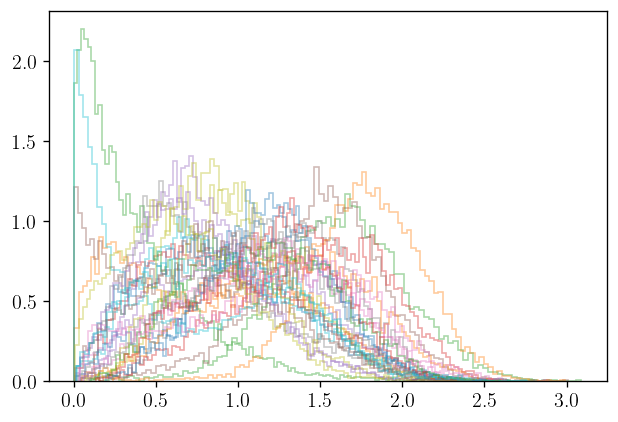

In [10]:
fig, ax = plt.subplots()

for i in range(n_run):
    ax.hist(samples[i], bins=100, histtype='step', density=True, alpha=0.4)

In [14]:
k = 'zs'

samples = []
for i in range(n_run):
    s = pickle.load(open(f'../outputs/fit/{run_name}/i{i}_n10000_ns0.p', 'rb'))
    samples.append(s[k])

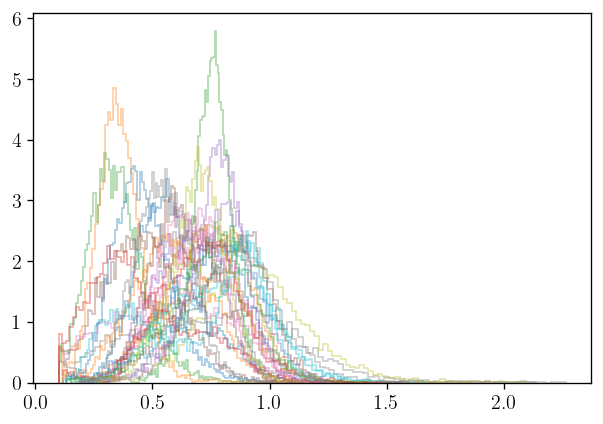

In [15]:
fig, ax = plt.subplots()

for i in range(n_run):
    ax.hist(samples[i], bins=100, histtype='step', density=True, alpha=0.4)